# Notebook 04 — Feature Engineering

> Goal: create & validate transformations (impute, scale, encode, + a few domain-inspired features), fit only on train, and save a reusable preprocessor.

## 01) Setup (Colab-friendly) + imports

In [42]:
# (Colab only) mount and set project root
IN_COLAB = "google.colab" in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction

# imports
import os, sys
sys.path.append(os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer, FunctionTransformer
from sklearn.impute import SimpleImputer

from src.data import PROC_DIR  # data/processed path produced by Notebook 02 or src/data.py

# ensure paths exist
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction


## 02) Load train/val/test split

In [2]:
X_train = pd.read_csv(PROC_DIR / "X_train.csv")
y_train = pd.read_csv(PROC_DIR / "y_train.csv").squeeze("columns")
X_val   = pd.read_csv(PROC_DIR / "X_val.csv")
y_val   = pd.read_csv(PROC_DIR / "y_val.csv").squeeze("columns")
X_test  = pd.read_csv(PROC_DIR / "X_test.csv")
y_test  = pd.read_csv(PROC_DIR / "y_test.csv").squeeze("columns")

X_train.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,46.0,1.0,4.0,120.0,249.0,0.0,2.0,144.0,0.0,0.8,1.0,0.0,7.0
1,41.0,1.0,3.0,130.0,214.0,0.0,2.0,168.0,0.0,2.0,2.0,0.0,3.0
2,35.0,1.0,4.0,120.0,198.0,0.0,0.0,130.0,1.0,1.6,2.0,0.0,7.0
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0
4,67.0,1.0,4.0,100.0,299.0,0.0,2.0,125.0,1.0,0.9,2.0,2.0,3.0


## 03) Define base feature group

In [3]:
NUM_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CAT_COLS = ["sex", "fbs", "exang", "restecg", "slope", "ca", "thal", "cp"]

assert set(NUM_COLS).issubset(X_train.columns)
assert set(CAT_COLS).issubset(X_train.columns)

## 4) Create derived features (domain-inspired, safe)

We'll add a few intuitive engineered features:

* hr_reserve = thalach / (220 - age) (cap to reasonable range)

* bp_per_age = trestbps / age

* chol_per_age = chol / age

* age_bin (5 quantile bins, later one-hot)

We’ll do this via a FunctionTransformer so it’s reproducible and serializable.

In [6]:
#import the engineering feature function from src.features
from src.features import add_derived_features
from sklearn import set_config

# FunctionTransformer wrapper (works inside sklearn pipelines)
deriver = FunctionTransformer(add_derived_features, validate=False)

# Set the output of the transformer to pandas DataFrame to preserve column names
deriver.set_output(transform="pandas")

# quick preview on train
_xt = deriver.fit_transform(X_train)
_xt[["age","thalach","hr_reserve","bp_per_age","chol_per_age","age_bin"]].head()

,age,thalach,hr_reserve,bp_per_age,chol_per_age,age_bin
0,46.0,144.0,0.827586,2.608696,5.413043,1
1,41.0,168.0,0.938547,3.170732,5.219512,0
2,35.0,130.0,0.702703,3.428571,5.657143,0
3,64.0,105.0,0.673077,2.000000,4.109375,4
4,67.0,125.0,0.816993,1.492537,4.462687,4


## 5) Build preprocessing pipelines

* Numeric: impute median → standardize

* Categorical: impute most_frequent → one-hot

* Age bin (engineered categorical): treat as categorical one-hot

* We run the deriver first, then column-wise transformers.

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

def get_feature_names(preproc: Pipeline,
                      num_cols: list[str],
                      cat_cols: list[str],
                      engineered_num: list[str],
                      engineered_cat: list[str]) -> list[str]:
    """
    Extract final feature names from a fitted preprocessing pipeline:
      preproc = Pipeline([("derive", ...), ("cols", ColumnTransformer(...))])
    """
    # 1) Access the ColumnTransformer inside the pipeline
    if not isinstance(preproc, Pipeline) or "cols" not in preproc.named_steps:
        raise TypeError("Expected preproc to be a Pipeline with a 'cols' step (ColumnTransformer).")
    ct = preproc.named_steps["cols"]

    # 2) Build the post-derivation column lists (in the same order you gave ct)
    derived_numeric = num_cols + engineered_num
    derived_categor = cat_cols + engineered_cat

    # 3) Find the categorical pipeline and its OneHotEncoder
    cat_trf = ct.named_transformers_.get("cat")
    if cat_trf is None:
        raise KeyError("ColumnTransformer has no 'cat' transformer. Check the name used in transformers=[('cat', ...)].")

    # cat_trf should be a Pipeline; find the OHE step robustly
    if not isinstance(cat_trf, Pipeline):
        raise TypeError("Expected the 'cat' transformer to be a Pipeline.")
    # try to find OneHotEncoder
    if "onehot" in cat_trf.named_steps:
        ohe = cat_trf.named_steps["onehot"]
    elif "onehotencoder" in cat_trf.named_steps:
        ohe = cat_trf.named_steps["onehotencoder"]
    else:
        # fallback: scan for an OHE
        ohe = next((s for s in cat_trf.named_steps.values() if isinstance(s, OneHotEncoder)), None)
        if ohe is None:
            raise KeyError("No OneHotEncoder step found in the 'cat' pipeline.")

    # 4) Numeric names pass through scaler unchanged
    num_names = derived_numeric

    # 5) One-hot names expand categorical inputs
    ohe_out = list(ohe.get_feature_names_out(derived_categor))

    return num_names + ohe_out


In [20]:
ENGINEERED_CAT = ["age_bin"]                 # produced by deriver
ENGINEERED_NUM = ["hr_reserve","bp_per_age","chol_per_age"]  # produced by deriver

num_cols_all = NUM_COLS + ENGINEERED_NUM
cat_cols_all = CAT_COLS + ENGINEERED_CAT

# 1) Build your pipes with explicit names (so 'onehot' exists)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols_all),
        ("cat", cat_pipe, cat_cols_all),
    ],
    remainder="drop"
)


# Full preprocessor = [derive features] -> [column transformers]
full_preproc = Pipeline([
    ("derive", deriver),        # your FunctionTransformer(add_derived_features)
    ("cols", preprocessor),
])

# Move the fitting and transformation steps before getting feature names
full_preproc.fit(X_train, y_train)

Xtr = full_preproc.transform(X_train)
Xva = full_preproc.transform(X_val)
Xte = full_preproc.transform(X_test)

print(Xtr.shape, Xva.shape, Xte.shape)


# 3) Now call with the ACTUAL lists (not strings) AFTER FITTING
feat_names = get_feature_names(
    full_preproc,
    num_cols=NUM_COLS,                # e.g., ["age","trestbps","chol","thalach","oldpeak"]
    cat_cols=CAT_COLS,                # e.g., ["sex","fbs","exang","restecg","slope","ca","thal","cp"]
    engineered_num=ENGINEERED_NUM,
    engineered_cat=ENGINEERED_CAT,
)

print(len(feat_names))
print(feat_names[:10])

(194, 36) (49, 36) (61, 36)
36
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'hr_reserve', 'bp_per_age', 'chol_per_age', 'sex_0.0', 'sex_1.0']


## Fit only on training data (avoid leakage) and inspect shape

In [22]:
full_preproc.fit(X_train, y_train)

Xtr = full_preproc.transform(X_train)
Xva = full_preproc.transform(X_val)
Xte = full_preproc.transform(X_test)

Xtr.shape, Xva.shape, Xte.shape


((194, 36), (49, 36), (61, 36))

## 7) Get feature names (useful for interpretation)

In [24]:
# Access the ColumnTransformer within the Pipeline
ct = full_preproc.named_steps['cols']

# Now you can access attributes of the ColumnTransformer
print([name for name, _, _ in ct.transformers_])  # e.g., ['num', 'cat']
print(ct.named_transformers_['cat'])               # prints the cat Pipeline
print(ct.named_transformers_['cat'].named_steps)   # shows step nam

['num', 'cat']
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
{'imputer': SimpleImputer(strategy='most_frequent'), 'onehot': OneHotEncoder(handle_unknown='ignore', sparse_output=False)}


## Quick sanity plots (Optional)

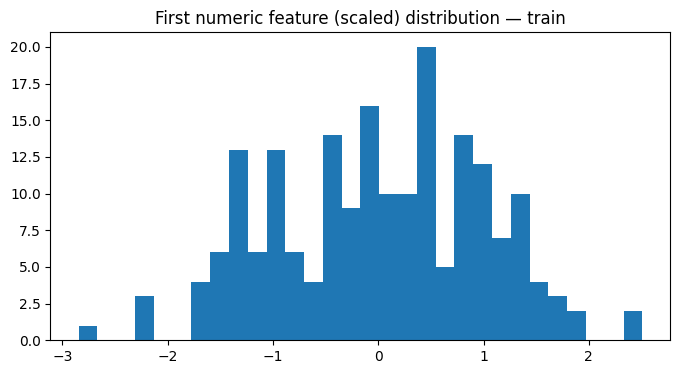

In [31]:
plt.figure(figsize=(8,4))
plt.hist(Xtr[:,0], bins=30)  # first numeric feature post-scaling
plt.title("First numeric feature (scaled) distribution — train")
plt.show()

## Save the fitted preprocessor for reuse

This is what your training code will load and reuse (or it can be kept embedded in a model pipeline)

In [45]:
import joblib
joblib.dump(full_preproc, "models/preprocessor.pkl")
print("💾 Saved fitted preprocessor → models/preprocessor.pkl")

💾 Saved fitted preprocessor → models/preprocessor.pkl


## 9) Save transformed arrays


We could save transformed matrices or keep the transform within the model pipeline

In [46]:
np.savez_compressed("data/processed/X_train_prepared.npz", Xtr)
np.savez_compressed("data/processed/X_val_prepared.npz",   Xva)
np.savez_compressed("data/processed/X_test_prepared.npz",  Xte)
print("💾 Saved transformed splits to data/processed/*.npz")


💾 Saved transformed splits to data/processed/*.npz


##  10) Minimal check with a simple model (no tuning here)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

clf = LogisticRegression(max_iter=200)
clf.fit(Xtr, y_train)

proba = clf.predict_proba(Xva)[:, 1]
auc = roc_auc_score(y_val, proba)
print(f"Quick AUC on validation (sanity check): {auc:.3f}")


Quick AUC on validation (sanity check): 0.962


### Decisions
- Engineered features: `hr_reserve`, `bp_per_age`, `chol_per_age`, and `age_bin`.
- Fitted imputation/scaling/encoding on **train only**; reused on val/test.
- Saved the fitted preprocessor to `models/preprocessor.pkl`.

### Next
Use this preprocessor inside `src/features.py` or load it in `05_model_training.ipynb`
and attach it in a full pipeline: `Pipeline([("pre", preproc), ("model", ...)])`.
